In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [153]:
# 파일 경로 지정
file_path = '/content/라벨포함.csv'

import pandas as pd
# CSV 파일 불러오기
df = pd.read_csv(file_path)
df.head(3)

,회사명,거래소코드,회계년도,유동자산(*)(IFRS연결)(천원),유동부채(*)(IFRS연결)(천원),자산(*)(IFRS연결)(천원),기말이익잉여금(결손금)(*)(IFRS연결)(천원),당기순이익(손실)(IFRS연결)(천원),법인세비용(IFRS연결)(천원),이자비용(IFRS연결)(천원),...,PBR(최고)(IFRS),PBR(최저)(IFRS),PCR(최고)(IFRS),PCR(최저)(IFRS),PSR(최고)(IFRS),PSR(최저)(IFRS),기업가치(EV)(IFRS)(백만원),EBITDA(IFRS)(백만원),감사의견코드,라벨
0,(주)CMG제약,58820,Dec.24,"134,859,155","31,457,218","303,436,817","13,893,853","2,694,712","185,614",0,...,2.05,1.29,642.8,404.77,3.57,2.25,"322,125.72","4,704.22",UQ,NaN
1,(주)ES큐브,50120,Dec.24,"26,261,494","2,041,697","90,410,906","-10,846,941","909,489","403,329",0,...,0.49,0.21,8.64,3.72,3.83,1.65,"19,037.92","-1,386.09",UQ,NaN
2,(주)MH에탄올,23150,Dec.24,"60,311,748","290,086,194","401,701,921","69,511,669","-19,633,918","4,306,514",0,...,0.77,0.50,9.24,6.04,0.96,0.63,"87,253.50","8,005.43",UQ,NaN


In [154]:
df= df.drop(columns = ['회계년도'])
num_cols = [c for c in df.columns if c not in ['회사명', '거래소코드','감사의견코드']]
df = df.replace(',', '', regex=True)
df
df[num_cols] = df[num_cols].astype(float)

In [155]:
keep_cols = [
    '회사명',
    '거래소코드',
    '라벨',
    '타인자본구성비율(IFRS연결)',
    '유동비율(IFRS연결)',
    '순운전자본비율(IFRS연결)',
    '차입금의존도(IFRS연결)',
    '유보액대비율(IFRS연결)',
    '자기자본증가율(IFRS연결)',
    '유동부채비율(IFRS연결)',
    '유보율(IFRS연결)',
    '매출액총이익률(IFRS연결)',
    '매입채무 대 재고자산비율(IFRS연결)'
]
df_scaled = df[keep_cols].copy()
df_scaled.head(3)

,회사명,거래소코드,라벨,타인자본구성비율(IFRS연결),유동비율(IFRS연결),순운전자본비율(IFRS연결),차입금의존도(IFRS연결),유보액대비율(IFRS연결),자기자본증가율(IFRS연결),유동부채비율(IFRS연결),유보율(IFRS연결),매출액총이익률(IFRS연결),매입채무 대 재고자산비율(IFRS연결)
0,(주)CMG제약,58820,NaN,37.53,428.71,34.08,26.35,39.58,-0.36,16.60,172.93,46.14,50.50
1,(주)ES큐브,50120,NaN,4.99,1286.26,26.79,2.00,19.71,4.09,2.38,25.79,13.12,7.15
2,(주)MH에탄올,23150,NaN,80.81,20.79,-57.20,48.75,19.67,-7.63,376.23,1443.95,37.46,4.50


In [156]:
df_scaled.라벨 = df_scaled.라벨.astype(object)
df_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2449 entries, 0 to 2448
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   회사명                    2449 non-null   object 
 1   거래소코드                  2449 non-null   object 
 2   라벨                     85 non-null     object 
 3   타인자본구성비율(IFRS연결)       1983 non-null   float64
 4   유동비율(IFRS연결)           1983 non-null   float64
 5   순운전자본비율(IFRS연결)        1983 non-null   float64
 6   차입금의존도(IFRS연결)         1983 non-null   float64
 7   유보액대비율(IFRS연결)         1983 non-null   float64
 8   자기자본증가율(IFRS연결)        1983 non-null   float64
 9   유동부채비율(IFRS연결)         1983 non-null   float64
 10  유보율(IFRS연결)            1983 non-null   float64
 11  매출액총이익률(IFRS연결)        1983 non-null   float64
 12  매입채무 대 재고자산비율(IFRS연결)  1983 non-null   float64
dtypes: float64(10), object(3)
memory usage: 248.9+ KB


In [157]:
# 1) 우선 사용할 열만 선택
df2 = df[keep_cols].copy()

# 2) 라벨은 제외하고 나머지 컬럼 리스트 만들기
cols_except_label = [col for col in keep_cols if col != '라벨']

# 3) 라벨은 건드리지 않고, 나머지 컬럼들 중 하나라도 NaN이면 drop
df_clean = df2.dropna(subset=cols_except_label)

df_clean.head()
df_clean.isnull().sum()

,0
회사명,0
거래소코드,0
라벨,1902
타인자본구성비율(IFRS연결),0
유동비율(IFRS연결),0
순운전자본비율(IFRS연결),0
차입금의존도(IFRS연결),0
유보액대비율(IFRS연결),0
자기자본증가율(IFRS연결),0
유동부채비율(IFRS연결),0


In [158]:
df_clean['라벨'] = df_clean['라벨'].astype('object')
float_cols = df_clean.select_dtypes(include='float').columns
df_clean.select_dtypes(include='float').columns
df_clean.head(3)

/tmp/ipython-input-621029857.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['라벨'] = df_clean['라벨'].astype('object')


,회사명,거래소코드,라벨,타인자본구성비율(IFRS연결),유동비율(IFRS연결),순운전자본비율(IFRS연결),차입금의존도(IFRS연결),유보액대비율(IFRS연결),자기자본증가율(IFRS연결),유동부채비율(IFRS연결),유보율(IFRS연결),매출액총이익률(IFRS연결),매입채무 대 재고자산비율(IFRS연결)
0,(주)CMG제약,58820,NaN,37.53,428.71,34.08,26.35,39.58,-0.36,16.60,172.93,46.14,50.50
1,(주)ES큐브,50120,NaN,4.99,1286.26,26.79,2.00,19.71,4.09,2.38,25.79,13.12,7.15
2,(주)MH에탄올,23150,NaN,80.81,20.79,-57.20,48.75,19.67,-7.63,376.23,1443.95,37.46,4.50


In [159]:
# float 컬럼들 강제 변환
for col in float_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

/tmp/ipython-input-2621606474.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')


In [160]:
from sklearn.model_selection import train_test_split

df_clean_81 = df_clean[df_clean['라벨'].isin([0,1])]

_,df_clean_test = train_test_split(df_clean_81,test_size=0.2, random_state=42)
df_clean_train = df_clean[~df_clean['회사명'].isin(df_clean_test['회사명'])]

In [161]:
# # import winsorize  <-- 불필요합니다. clip을 쓰면 됩니다.
# wins_low = {}
# wins_high = {}

# # 1. Train Set 기준으로 기준값 계산
# for col in float_cols:
#     wins_low[col]  = df_clean_train[col].quantile(0.01)
#     wins_high[col] = df_clean_train[col].quantile(0.99)

# # 2. clip 함수를 사용하여 Train과 Test 모두 'Train 기준값'으로 자르기
# for col in float_cols:
#     # Train 변환
#     df_clean_train[col] = df_clean_train[col].clip(lower=wins_low[col], upper=wins_high[col])

#     # Test 변환 (Train에서 구한 wins_low, wins_high를 그대로 사용)
#     df_clean_test[col] = df_clean_test[col].clip(lower=wins_low[col], upper=wins_high[col])

In [162]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson', standardize=True) # 사이킷런 여존슨은 standardscaler 기능까지 포함됨: default=True
df_clean_train[float_cols] = pt.fit_transform(df_clean_train[float_cols])
df_clean_test[float_cols] = pt.transform(df_clean_test[float_cols])
df_clean_train[float_cols]

/tmp/ipython-input-2848879010.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean_train[float_cols] = pt.fit_transform(df_clean_train[float_cols])


,타인자본구성비율(IFRS연결),유동비율(IFRS연결),순운전자본비율(IFRS연결),차입금의존도(IFRS연결),유보액대비율(IFRS연결),자기자본증가율(IFRS연결),유동부채비율(IFRS연결),유보율(IFRS연결),매출액총이익률(IFRS연결),매입채무 대 재고자산비율(IFRS연결)
0,-0.055602,1.094453,0.589568,0.452007,-0.501774,-0.095280,-0.982112,-0.281407,0.493267,0.216455
1,-2.320344,2.102901,0.286370,-1.426683,-1.247525,0.012723,-2.439951,-0.328711,-0.555360,-0.805495
2,1.464233,-3.127588,-2.078495,1.323970,-1.248930,-0.332904,1.986217,-0.068523,0.178373,-1.030909
3,-0.543171,1.300435,1.390450,-0.307903,-1.090639,-0.466050,-0.957558,-0.319594,-0.800240,-0.904768
4,0.218771,-0.252498,-0.244183,0.363587,0.192891,0.008266,0.356430,-0.015108,-0.636470,-0.597701
...,...,...,...,...,...,...,...,...,...,...
2443,2.030805,-2.231961,-2.153341,2.293413,-1.848158,-9.888518,-3.457720,-3.474921,-0.818985,0.356073
2444,-0.098078,-0.019714,0.074642,-0.154820,-0.199371,1.623781,0.122517,-0.293702,-0.603296,0.577254
2445,-0.687223,0.562243,0.821229,-1.074466,1.586785,-0.806940,-0.384047,0.013576,-0.738083,-1.268772
2446,-1.710534,1.755324,1.233531,-1.128663,3.249855,0.087250,-1.662061,1.158401,1.774794,-0.625722


In [163]:
# from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# scaler = StandardScaler() # << 여존슨에 포함됨
# df_clean_train[float_cols] = scaler.fit_transform(df_clean_train[float_cols])
# df_clean_test[float_cols] = scaler.transform(df_clean_test[float_cols])
# df_clean_train[float_cols]

In [164]:
import numpy as np
from sklearn.semi_supervised import LabelSpreading

# 1) 피처 컬럼 선정
#    - df_clean에서 숫자형(float/int) 컬럼만 가져옴
#    - 그 중 '라벨'과, 기존에 만들어 둔 확률/예측 컬럼은 제외
exclude_cols = ['라벨', '회사명','거래소코드']

feature_cols = df_clean_train.select_dtypes(include=['float64']).columns.tolist()
feature_cols = [c for c in feature_cols if c not in exclude_cols]

# 2) X, y_semi 만들기
X_train = df_clean_train[feature_cols].values
X_test = df_clean_test[feature_cols].values
y_train = df_clean_train['라벨'].copy()
y_test = df_clean_test['라벨'].copy()

# 0/1 은 그대로 두고, 라벨 없는 애(NaN)는 -1로 처리 → 반지도용
y_semi = np.where(y_train.isin([0, 1]), y_train, -1).astype(float)


# 3) LabelSpreading 모델 정의 (1이 ~100개 나오게 튜닝된 파라미터)
model_ls = LabelSpreading(
    kernel='rbf',
    alpha=0.5,
    gamma = 0.2,
    max_iter=50,
)

model_ls.fit(X_train, y_semi)

# 4) 확률 & 최종 라벨 예측
proba = model_ls.predict_proba(X_train)      # shape: (n_samples, 2)  → [P(0), P(1)] (클래스 순서에 따라 달라짐)
classes = list(model_ls.classes_)      # 예: [0., 1.]
idx1 = classes.index(1.0)             # 1 클래스의 인덱스

prob1_ls_v2 = proba[:, idx1]          # P(label=1)
y_pred_ls_v2 = model_ls.transduction_ # 최종 0/1 예측

# 5) df_clean에 붙이기 (버전2 느낌으로 새 컬럼명)
df_clean_train['prob1_ls_v2'] = prob1_ls_v2
df_clean_train['label_pred_ls_v2'] = y_pred_ls_v2

# 6) 개수 확인
total_1 = (df_clean_train['label_pred_ls_v2'] == 1).sum()
total_0 = (df_clean_train['label_pred_ls_v2'] == 0).sum()

print("=== LabelSpreading (alpha=0.5, gamma=0.2) 결과 ===")
print("1로 분류된 기업 수:", total_1)
print("0로 분류된 기업 수:", total_0)

# 라벨 미지정(NaN) 중 새로 1로 분류된 애들 수
unlabeled_mask = df_clean_train['라벨'].isna()
new_1 = ((df_clean_train['label_pred_ls_v2'] == 1) & unlabeled_mask).sum()
print(df_clean_train['label_pred_ls_v2'].isna().sum())
print("미라벨 중 새로 1로 분류된 기업 수:", new_1)
# df_clean_train.head(3)

=== LabelSpreading (alpha=0.5, gamma=0.2) 결과 ===
1로 분류된 기업 수: 837
0로 분류된 기업 수: 1129
0
미라벨 중 새로 1로 분류된 기업 수: 812


/tmp/ipython-input-2981467630.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean_train['prob1_ls_v2'] = prob1_ls_v2
/tmp/ipython-input-2981467630.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean_train['label_pred_ls_v2'] = y_pred_ls_v2


Q25, Q50, Q75: 0.24919818473192212 0.4492271489147455 0.5828492207725541
min, max: 0.00647975948392925 0.9999997605800929


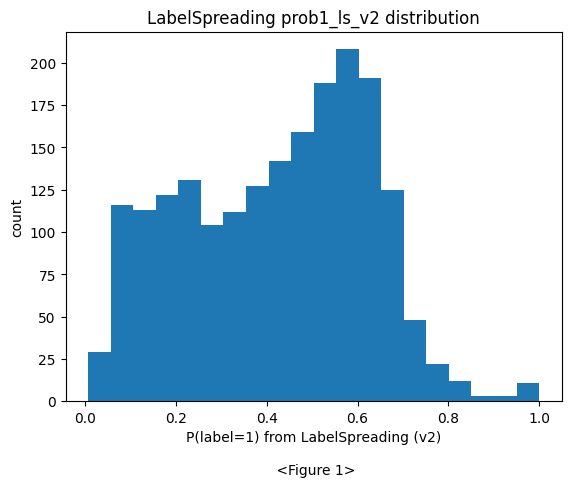

In [165]:
import matplotlib.pyplot as plt

prob_clean = df_clean_train['prob1_ls_v2'].values
prob_clean = prob_clean[~np.isnan(prob_clean)]

print("Q25, Q50, Q75:",
      *np.percentile(prob_clean, [25, 50, 75]))
print("min, max:", prob_clean.min(), prob_clean.max())

plt.hist(prob_clean, bins=20)
plt.xlabel("P(label=1) from LabelSpreading (v2)\n\n <Figure 1>")
plt.ylabel("count")
plt.title("LabelSpreading prob1_ls_v2 distribution")
plt.show()


In [166]:
# LabelSpreading 확률
p = df_clean_train['prob1_ls_v2'].values

# cutoff 설정
high_th = 0.9
low_th  = 0.4

# pseudo-label 초기화
y_pseudo = np.full_like(p, np.nan)

#########순서바꿈###################
# 1) 원래 라벨은 그대로
mask_orig = df_clean_train['라벨'].isin([0, 1])
y_pseudo[mask_orig] = df_clean_train.loc[mask_orig, '라벨']
print(y_pseudo[mask_orig])
print(p[mask_orig])

# 2) high / low 구간 pseudo-label
y_pseudo[p >= high_th] = 1
y_pseudo[p <= low_th]  = 0
print(y_pseudo[mask_orig])

#####################################

# 학습에 사용할 index
train_mask = ~np.isnan(y_pseudo)
X_pseudo = X_train[train_mask]
y_pseudo_clean = y_pseudo[train_mask].astype(int)



print("Pseudo label count:")
print("Label=1:", (y_pseudo_clean == 1).sum())
print("Label=0:", (y_pseudo_clean == 0).sum())
print("Excluded:", len(p) - len(y_pseudo_clean))

[1. 0. 1. 1. 0. 1. 0. 0. 0. 0. 1. 1. 0. 0. 1. 1. 1. 0. 0. 0. 1. 1. 1. 1.
 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0.
 1. 0. 1. 0. 0. 0. 1. 1. 1. 0. 1. 0. 1. 0. 0. 0.]
[0.70148143 0.12340778 0.8458867  0.63022294 0.05140217 0.98854602
 0.05310175 0.08638473 0.0693271  0.39373468 0.64771633 0.82986316
 0.07636858 0.13921951 0.98077985 0.61026718 0.96786532 0.17336756
 0.04899123 0.09944081 0.49106189 0.75605153 0.51018737 0.76839237
 0.09873894 0.13219288 0.05891277 0.95199922 0.08050098 0.04235089
 0.41632427 0.04145538 0.9983154  0.1136854  0.05979078 0.04517822
 0.05951505 0.68014449 0.09708519 0.102507   0.03248901 0.05835539
 0.09177016 0.59955618 0.8663364  0.99999976 0.18819707 0.05211677
 0.87295044 0.08590678 0.96047877 0.0714244  0.40296493 0.15481934
 0.94319197 0.6710742  0.49014496 0.05968574 0.19215127 0.11483952
 0.84237554 0.17512335 0.20809628 0.06911907]
[1. 0. 1. 1. 0. 1. 0. 0. 0. 0. 1. 1. 0. 0. 1. 1. 1. 0. 0. 0. 1. 1. 1. 1.
 0. 0. 0. 1. 0.

In [255]:
from xgboost import XGBClassifier

# XGBoost 분류기 (적당한 기본 설정)
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)

xgb.fit(X_pseudo, y_pseudo_clean)
# len(X_pseudo[0])

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [256]:
print(X_train)
print(f'X길이:{len(X_train)}')
print(X_pseudo)
print(f'X_pseudo길이:{len(X_pseudo)}')

[[-0.05560194  1.09445275  0.58956826 ... -0.28140725  0.49326672
   0.21645507]
 [-2.32034376  2.1029008   0.28636967 ... -0.32871095 -0.55535966
  -0.8054953 ]
 [ 1.46423328 -3.12758833 -2.07849506 ... -0.06852342  0.17837342
  -1.0309087 ]
 ...
 [-0.68722264  0.5622433   0.82122924 ...  0.01357555 -0.73808291
  -1.2687722 ]
 [-1.7105337   1.75532399  1.23353122 ...  1.1584012   1.7747944
  -0.6257223 ]
 [ 0.35093143 -0.05420932 -0.44696361 ... -0.30478496 -0.25159965
   0.80073375]]
X길이:1966
[[-0.05560194  1.09445275  0.58956826 ... -0.28140725  0.49326672
   0.21645507]
 [-2.32034376  2.1029008   0.28636967 ... -0.32871095 -0.55535966
  -0.8054953 ]
 [-0.54317053  1.30043475  1.39044958 ... -0.31959384 -0.80024039
  -0.9047681 ]
 ...
 [ 2.03080542 -2.23196064 -2.15334058 ... -3.4749208  -0.81898545
   0.356073  ]
 [-0.68722264  0.5622433   0.82122924 ...  0.01357555 -0.73808291
  -1.2687722 ]
 [-1.7105337   1.75532399  1.23353122 ...  1.1584012   1.7747944
  -0.6257223 ]]
X_pseudo길

In [257]:
# 전체 기업(레이블 유무 상관없이)에 대한 XGBoost 확률 예측
prob_xgb = xgb.predict_proba(X_train)[:, 1]   # P(label=1)
df_clean_train['prob_xgb'] = prob_xgb

# 기본 threshold 0.8로 분류
df_clean_train['pred_xgb'] = (df_clean_train['prob_xgb'] >= 0.80).astype(int)

print("XGB 기준 1로 분류된 기업 수:", (df_clean_train['pred_xgb'] == 1).sum())
print("XGB 기준 0로 분류된 기업 수:", (df_clean_train['pred_xgb'] == 0).sum())

XGB 기준 1로 분류된 기업 수: 343
XGB 기준 0로 분류된 기업 수: 1623


/tmp/ipython-input-690047351.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean_train['prob_xgb'] = prob_xgb
/tmp/ipython-input-690047351.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean_train['pred_xgb'] = (df_clean_train['prob_xgb'] >= 0.80).astype(int)


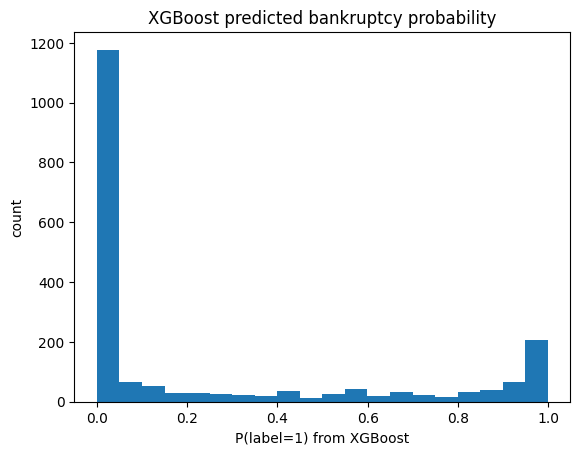

,회사명,거래소코드,라벨,prob1_ls_v2,prob_xgb
496,(주)셀레스트라,352770,1.0,0.980780,0.999216
100,(주)노블엠앤비,106520,1.0,0.845887,0.999216
1047,(주)이엔플러스,74610,1.0,0.951999,0.999216
568,(주)심텍홀딩스,36710,NaN,0.847013,0.999216
1428,(주)프로브잇,227100,1.0,0.866336,0.999216
2166,일성건설(주),13360,NaN,0.745897,0.999216
5,(주)STX,11810,NaN,0.761840,0.999216
2411,해성옵틱스(주),76610,NaN,0.837687,0.999216
1823,삼부토건(주),1470,1.0,0.960479,0.999216
1854,삼화전자공업(주),11230,NaN,0.752480,0.999216


In [258]:
import matplotlib.pyplot as plt
import numpy as np

# 확률 분포
plt.hist(df_clean_train['prob_xgb'], bins=20)
plt.xlabel("P(label=1) from XGBoost")
plt.ylabel("count")
plt.title("XGBoost predicted bankruptcy probability")
plt.show()

# 상위 위험 20개 기업 리스트 확인
top20 = df_clean_train.sort_values('prob_xgb', ascending=False).head(50)
display(top20[['회사명', '거래소코드', '라벨', 'prob1_ls_v2', 'prob_xgb']])


In [259]:
df_clean_train.head(3)

,회사명,거래소코드,라벨,타인자본구성비율(IFRS연결),유동비율(IFRS연결),순운전자본비율(IFRS연결),차입금의존도(IFRS연결),유보액대비율(IFRS연결),자기자본증가율(IFRS연결),유동부채비율(IFRS연결),유보율(IFRS연결),매출액총이익률(IFRS연결),매입채무 대 재고자산비율(IFRS연결),prob1_ls_v2,label_pred_ls_v2,prob_xgb,pred_xgb
0,(주)CMG제약,58820,NaN,-0.055602,1.094453,0.589568,0.452007,-0.501774,-0.095280,-0.982112,-0.281407,0.493267,0.216455,0.351815,0.0,0.001147,0
1,(주)ES큐브,50120,NaN,-2.320344,2.102901,0.286370,-1.426683,-1.247525,0.012723,-2.439951,-0.328711,-0.555360,-0.805495,0.126419,0.0,0.000176,0
2,(주)MH에탄올,23150,NaN,1.464233,-3.127588,-2.078495,1.323970,-1.248930,-0.332904,1.986217,-0.068523,0.178373,-1.030909,0.765287,1.0,0.878249,1


In [260]:
probs_labeled_1 = df_clean_train.loc[df_clean_train['label_pred_ls_v2'] == 0, 'prob1_ls_v2']
print(probs_labeled_1.sort_values(ascending=False))

2008    0.629640
1419    0.599556
53      0.551691
753     0.550734
305     0.509687
          ...   
1329    0.032489
618     0.025468
358     0.012614
969     0.008158
129     0.006480
Name: prob1_ls_v2, Length: 1129, dtype: float64


In [261]:
df_clean_train.to_csv('finall_ver2.csv', encoding='cp949', index=False)
res = pd.read_csv('finall_ver2.csv', encoding='cp949')

In [262]:
print(len(X_train))
print(len(X_pseudo))

1966
871


In [263]:
print(len(X_train[0]))

10


In [264]:
prob_xgb = xgb.predict_proba(X_test)[:, 1]
df_clean_test['prob_xgb'] = prob_xgb
print(df_clean_test['prob_xgb'].isna().sum())
df_clean_test['pred_xgb'] = (df_clean_test['prob_xgb'] >= 0.8).astype(int)  # ★ 반드시 0/1 int
len(df_clean_test['pred_xgb'])

0


17

In [265]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 라벨 있는 행만 사용 (0 또는 1)
mask_lab = df_clean_test['라벨'].isin([0, 1])
# print(df_clean_test['라벨'])
y_true = df_clean_test.loc[mask_lab, '라벨'].astype(int)       # ★ int로 강제
# print(y_true.value_counts())
y_pred = df_clean_test.loc[mask_lab, 'pred_xgb'].astype(int)   # ★ int로 강제
# print(y_pred.value_counts())


# print("y_true unique:", y_true.unique(), "dtype:", y_true.dtype)
# print("y_pred unique:", y_pred.unique(), "dtype:", y_pred.dtype)

cm = confusion_matrix(y_true, y_pred)
print(cm)

print(classification_report(y_true, y_pred))
print("Accuracy:", accuracy_score(y_true, y_pred))


[[12  0]
 [ 1  4]]
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       1.00      0.80      0.89         5

    accuracy                           0.94        17
   macro avg       0.96      0.90      0.92        17
weighted avg       0.95      0.94      0.94        17

Accuracy: 0.9411764705882353


In [266]:
df_clean_test.to_csv('test_result.csv', encoding='cp949', index=False)

# 36개 test

In [267]:
df_test_36 = pd.read_csv('test36.csv')
df_test_36.head(3)

,회사명,거래소코드,타인자본구성비율(IFRS연결),유동비율(IFRS연결),순운전자본비율(IFRS연결),차입금의존도(IFRS연결),유보액대비율(IFRS연결),자기자본증가율(IFRS연결),유동부채비율(IFRS연결),유보율(IFRS연결),매출액총이익률(IFRS연결),매입채무 대 재고자산비율(IFRS연결),라벨
0,(주)국보,1140,67.87,40.16,-35.75,44.75,-36.70,-30.53,185.97,-52.65,0.53,174.46,1
1,(주)노블엠앤비,106520,62.71,67.57,-16.34,31.08,-100.35,-29.89,135.13,-35.67,-39.15,190.12,1
2,(주)비유테크놀러지,230980,66.48,52.90,-29.49,33.57,15.10,-37.02,186.78,80.87,-9.58,12.33,1


In [268]:
X_36 = df_test_36.drop(['회사명','거래소코드','라벨'], axis=1)
y_36 = df_test_36['라벨']

In [269]:
# 스케일링
# for col in float_cols:
#     X_36[col] = X_36[col].clip(lower=wins_low[col], upper=wins_high[col])

X_36[float_cols] = pt.transform(X_36[float_cols])

# X_36[float_cols] = scaler.transform(X_36[float_cols])

In [270]:
prob_36 = xgb.predict_proba(X_36)[:, 1]
X_36['prob_xgb'] = prob_36
print(X_36['prob_xgb'].isna().sum())
X_36['pred_xgb'] = (X_36['prob_xgb'] >= 0.81).astype(int)
len(X_36['pred_xgb'])

0


36

In [271]:
cm = confusion_matrix(y_36, X_36['pred_xgb'])
print(cm)

print(classification_report(y_36, X_36['pred_xgb']))
print("Accuracy:", accuracy_score(y_36, X_36['pred_xgb']))


[[ 0  0]
 [ 9 27]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.75      0.86        36

    accuracy                           0.75        36
   macro avg       0.50      0.38      0.43        36
weighted avg       1.00      0.75      0.86        36

Accuracy: 0.75


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [272]:
len(float_cols)

10

# SHAP 해석

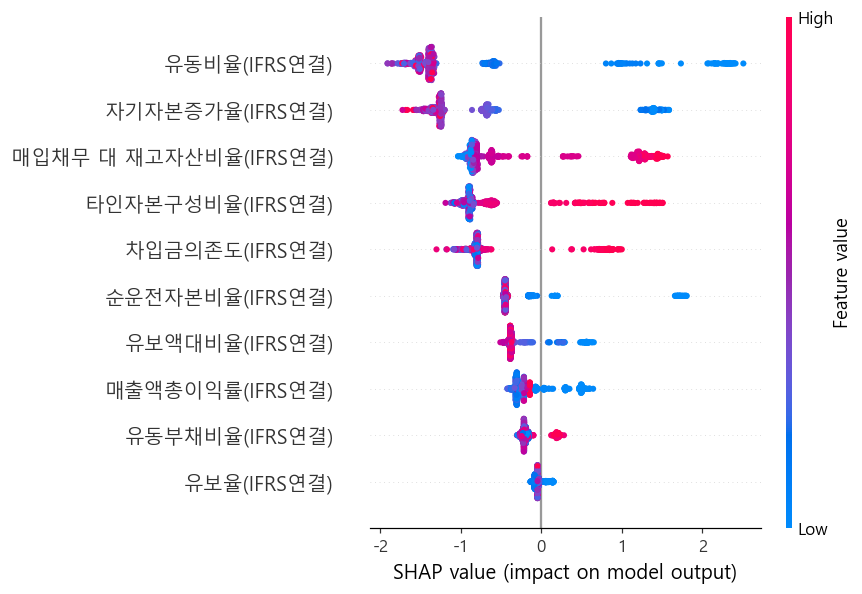

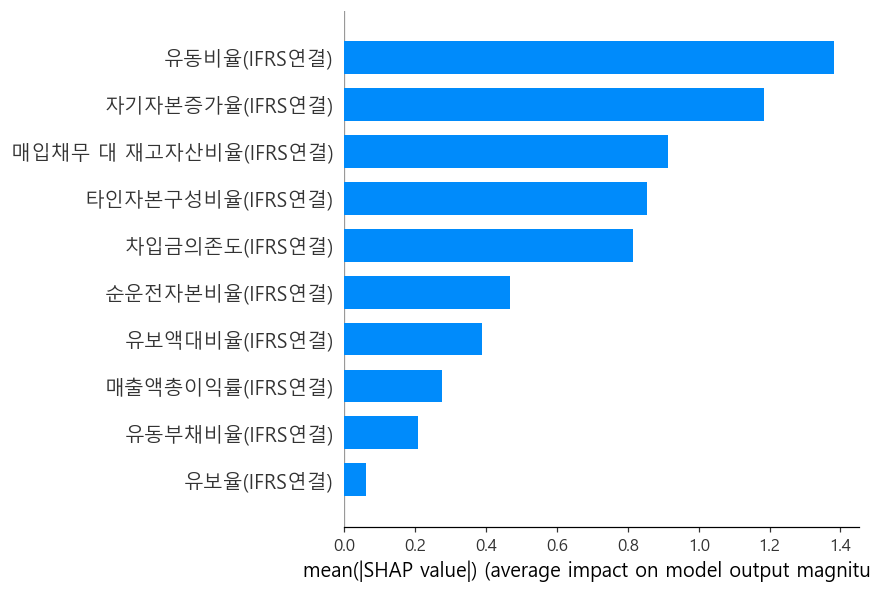

In [ ]:
import shap
import matplotlib.pyplot as plt

# 학습된 XGBoost 모델에 대한 SHAP 분석 (train pseudo-label 데이터 기준)
explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_pseudo)
if isinstance(shap_values, list):   # 이진분류 multi-output 대비
    shap_values = shap_values[1]

# 전체 summary plot (dot)
shap.summary_plot(shap_values, X_pseudo, feature_names=feature_cols)

# feature importance (bar)
shap.summary_plot(shap_values, X_pseudo, feature_names=feature_cols, plot_type='bar')

FN 기업 수: 9


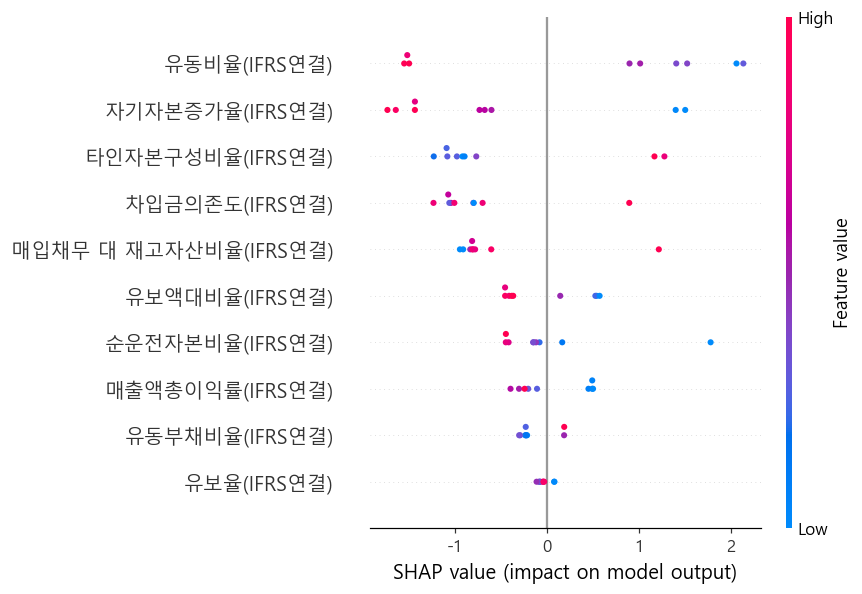

In [ ]:
# 36개 외부검증에서 FN(실제 1인데 0으로 예측)으로 오분류된 기업들의 SHAP 분석
fn_mask = (y_36.values == 1) & (X_36['pred_xgb'].values == 0)
print('FN 기업 수:', fn_mask.sum())

X_fn = X_36[feature_cols].values[fn_mask]
shap_values_fn = explainer.shap_values(X_fn)
if isinstance(shap_values_fn, list):
    shap_values_fn = shap_values_fn[1]

shap.summary_plot(shap_values_fn, X_fn, feature_names=feature_cols)